In [50]:
import pandas as pd

df = pd.read_parquet(r"C:\Users\user\Downloads\yellow_tripdata_2026-01.parquet")

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [51]:
df.shape

(3724889, 20)

In [52]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [54]:
df.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64

## Data Cleaning

In [55]:
df= df.drop(columns=[
    "store_and_fwd_flag",
    "Airport_fee"
])

In [56]:
df["passenger_count"] = df["passenger_count"].fillna(df["passenger_count"].median())

In [57]:
df["RatecodeID"] = df["RatecodeID"].fillna(df["RatecodeID"].mode()[0])

In [58]:
df["congestion_surcharge"] = df["congestion_surcharge"].fillna(0)

## Feature Engineering

In [59]:
df["trip_duration"] =( df["tpep_dropoff_datetime"]- df["tpep_pickup_datetime"]).dt.total_seconds()/60

### Removing invalid duration

In [60]:
df=df[(df["trip_duration"] > 1) & (df["trip_duration"] < 180)]

In [61]:
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day
df["pickup_weekday"] = df["tpep_pickup_datetime"].dt.weekday
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month

#### Revenue features 

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3639131 entries, 0 to 3724888
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   PULocationID           int32         
 7   DOLocationID           int32         
 8   payment_type           int64         
 9   fare_amount            float64       
 10  extra                  float64       
 11  mta_tax                float64       
 12  tip_amount             float64       
 13  tolls_amount           float64       
 14  improvement_surcharge  float64       
 15  total_amount           float64       
 16  congestion_surcharge   float64       
 17  cbd_congestion_fee     float64       
 18  trip_duration          floa

In [63]:
df["total_cost"] = (
    df["fare_amount"] +
    df["tip_amount"] +
    df["extra"] +
    df["tolls_amount"] 
    
)

#### Selecting features

In [64]:
features = [
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "pickup_hour",
    "pickup_day",
    "pickup_weekday",
    "pickup_month"
]
target = "trip_duration"

In [65]:
df.shape

(3639131, 24)

In [66]:
model_df = df[features + [target]]

In [67]:
import os
model_df.to_parquet(r"C:\Users\user\nyc-mobility-intelligence\data\processed/features.parquet")

In [68]:
df.shape

(3639131, 24)

In [69]:
X = model_df.drop("trip_duration",axis=1)
X.dtypes

passenger_count    float64
trip_distance      float64
RatecodeID         float64
PULocationID         int32
DOLocationID         int32
payment_type         int64
pickup_hour          int32
pickup_day           int32
pickup_weekday       int32
pickup_month         int32
dtype: object

In [70]:
from sklearn.model_selection import train_test_split

X = model_df.drop("trip_duration",axis=1)
y = model_df["trip_duration"]

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

print(X_train.shape)
print(y_train.shape)

(2911304, 10)
(2911304,)


#### As it is huge data ,we use sample 

In [71]:
sample_df = model_df.sample(n=50000,random_state=42)

In [72]:
X = sample_df.drop("trip_duration",axis=1)
y = sample_df["trip_duration"]

### Start training the data

In [73]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,
    random_state = 42
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

In [74]:
sample_df.shape

(50000, 11)

### Training baseline model

### Model Evaluation

In [75]:
!pip install lightgbm

### Evaluating more models

In [76]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

In [77]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pandas as pd
import time


In [78]:
models = {
    "Linear Regression" : LinearRegression(),
    "Decision Tree" : DecisionTreeRegressor(random_state=42),
    "XGBoost" : XGBRegressor(
        n_estimators=100,
        learning_rate = 0.1,
        max_depth = 6,
        random_state = 42,
        n_jobs=-1
    ),
    "Random Forest" : RandomForestRegressor(
        n_estimators = 100,
        random_state = 42,
        n_jobs = -1),
    "CatBoost": CatBoostRegressor(
        iterations =100,
        learning_rate=0.1,
        depth=6,
        random_state=42,
        verbose=0
    ),
    "LGBMRegressor" : LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
}

results =[]

for name,model in models.items():
    start_time = time.time()
    model.fit(X_train,y_train)
    preds = model.predict(X_test)
    end_time =time.time()

    mae = mean_absolute_error(y_test,preds)
    rmse = mean_squared_error(y_test,preds)
    r2 = r2_score(y_test,preds)

    results.append({
        "Model": name,
        "MAE" : round(mae,3),
        "RMSE" : round(rmse),
        "R2" : round(r2, 4),
        "Training Time(sec)" : round(end_time-start_time,2)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by ="R2",
    ascending=False,
    
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001819 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 778
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 9
[LightGBM] [Info] Start training from score 17.174615


,Model,MAE,RMSE,R2,Training Time(sec)
2,XGBoost,3.887,42,0.7789,0.46
5,LGBMRegressor,3.898,42,0.7788,0.38
4,CatBoost,4.064,44,0.7689,0.98
3,Random Forest,4.054,45,0.7627,4.24
1,Decision Tree,5.748,89,0.5266,0.59
0,Linear Regression,8.457,146,0.2273,0.16


In [79]:
import os
os.makedirs("../outputs", exist_ok=True)

In [80]:
results_df.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

## feature Importance

### Since XGboost is the best performing model here , we will retrain on larger sample data

In [81]:
sample_df=model_df.sample(
    n=200000,
    random_state =42
)

In [82]:
X = sample_df.drop("trip_duration",axis=1)
y = sample_df["trip_duration"]

In [83]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,
    random_state=42
)

In [84]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [85]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score

)
import numpy as np

preds = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test,preds))
mae = mean_absolute_error(y_test,preds)
r2 = r2_score(y_test,preds)

print("MAE :",mae)
print("RMSE :" ,rmse)
print("R2 :",r2)

MAE : 3.616949331215035
RMSE : 6.071959712988284
R2 : 0.8039140482365952


## Checking feature importance of xgboost

In [86]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

           Feature  Importance
2       RatecodeID    0.449886
1    trip_distance    0.345144
6      pickup_hour    0.049794
7       pickup_day    0.039414
5     payment_type    0.034422
8   pickup_weekday    0.031155
3     PULocationID    0.021907
4     DOLocationID    0.021141
0  passenger_count    0.007137
9     pickup_month    0.000000


In [87]:
df["RatecodeID"].value_counts()

RatecodeID
1.0     3414841
99.0     109655
2.0       79540
5.0       16304
3.0       10618
4.0        8171
6.0           2
Name: count, dtype: int64

In [88]:
df.groupby("RatecodeID")["trip_duration"].mean()

RatecodeID
1.0     15.226914
2.0     47.461912
3.0     33.357250
4.0     40.626162
5.0     27.722132
6.0      3.025000
99.0    51.963123
Name: trip_duration, dtype: float64

In [89]:
sample_row = X_test.iloc[[0]]

prediction = xgb_model.predict(sample_row)

print(prediction)

[7.259548]


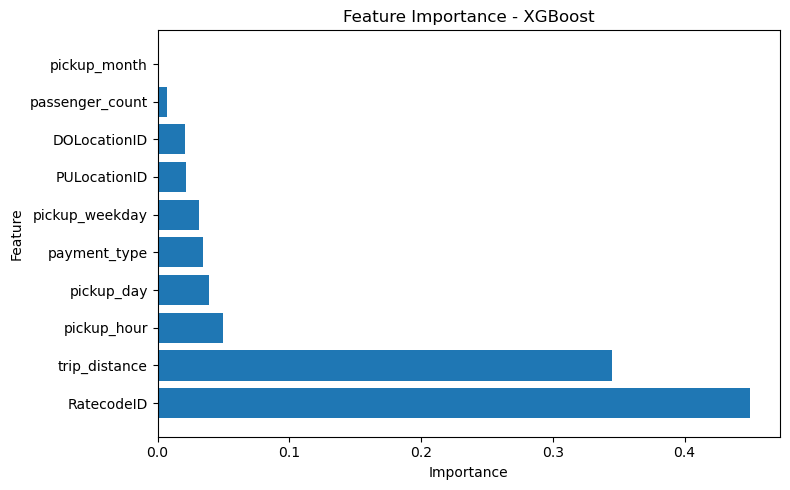

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - XGBoost")

plt.tight_layout()

plt.savefig(
    "../outputs/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

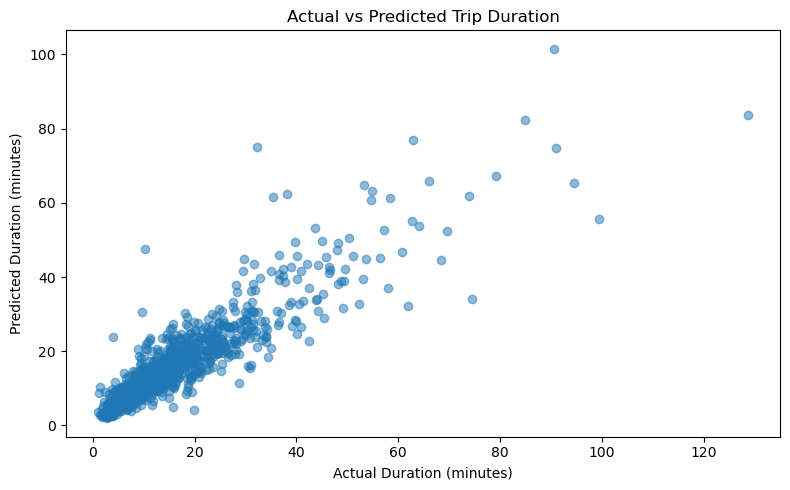

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    y_test[:1000],
    preds[:1000],
    alpha=0.5
)

plt.xlabel("Actual Duration (minutes)")
plt.ylabel("Predicted Duration (minutes)")
plt.title("Actual vs Predicted Trip Duration")

plt.tight_layout()

plt.savefig(
    "../outputs/actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

In [104]:
import os

BASE_DIR = os.path.abspath("..")  # go one level up from notebooks

model_dir = os.path.join(BASE_DIR, "models")
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "xgboost_trip_duration.json")

xgb_model.save_model(model_path)

print("Saved at:", model_path)

Saved at: C:\Users\user\nyc-mobility-intelligence\models\xgboost_trip_duration.json


In [105]:

importance_df.to_csv(
    "../outputs/feature_importance.csv",
    index=False
)

In [106]:
xgb_model.save_model("models/xgboost_trip_duration.json")